In [0]:
# Create schema to RetailCast data
spark.sql("""
CREATE SCHEMA IF NOT EXISTS p2_retailcast.retailcast_clean
""")

In [0]:
from pyspark.sql.functions import col, to_date, regexp_replace, trim, date_format

# ==================================================
# (1)  INFO LOJA
# ==================================================

# Register the DataFrame as a temporary view so we can run SQL queries
# Example SQL query on the temporary view
result_df_raw = spark.sql('SELECT * FROM p2_retailcast.default.retailcast_info_loja')
result_df_raw.show()


# Data Cleansing and Transformation
df_silver = result_df_raw.withColumnRenamed("CAIXAS TRADICIONAIS", "CAIXAS_TRADICIONAIS") \
                         .withColumnRenamed("SELF CHECKOUTS", "SELF_CHECKOUTS") \
                         .withColumn("SECAO", regexp_replace(col("SECAO"), "Frente de loja", "Frente de Loja")) \
                        .withColumn("LOJA", trim(col("LOJA"))) \
                        .withColumn("ABERTURA", date_format(col("ABERTURA"), "HH:mm")) \
                        .withColumn("FECHO", date_format(col("FECHO"), "HH:mm"))

### RESUMO DAS ALTERAÇÕES:
# 1) Renomear e correção de nomes de lojas.
# 2) Normalização dos nomes de lojas.
# 3) A coluna ABERTURA e FECHO teve o formato da hora alterado para o formato HH:mm.

# Write the transformed data to the Silver layer
silver_data_path = "p2_retailcast.retailcast_clean.retailcast_info_loja_clean"
df_silver.write.format("delta").mode("overwrite").saveAsTable(silver_data_path)

# Register the DataFrame as a temporary view so we can run SQL queries
df_silver.createOrReplaceTempView("retailcast_info_loja_clean")

# Example SQL query on the temporary view
result_df = spark.sql("SELECT COUNT(*) as trip_count FROM retailcast_info_loja_clean")

# Show the result of the query
result_df.show()

print("Silver layer processing completed.")

+-------+----------------+---------+--------------------+---------+--------------+--------+--------------+------------------+---------------+-----+-------------------+-------------------+-------------------+--------------+
|FK_LOJA|            LOJA|FK_CIDADE|              CIDADE|FK_REGIAO|        REGIAO|FK_SECAO|         SECAO|PRODUTIVIDADE/HORA|N_COLABORADORES| SKUS|           ABERTURA|              FECHO|CAIXAS TRADICIONAIS|SELF CHECKOUTS|
+-------+----------------+---------+--------------------+---------+--------------+--------+--------------+------------------+---------------+-----+-------------------+-------------------+-------------------+--------------+
| POR025|       Alfragide|      228|           Alfragide|       14|Lisboa Central|     976|Frente de Loja|               269|             85|35052|2000-01-01 08:00:00|2000-01-01 21:00:00|                 26|             8|
| POR012|    Almada Fórum|      164|              Almada|        3|    Margem Sul|      24|Frente de Loja|  

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, to_date, regexp_replace, trim, date_format, when, initcap, month, year, row_number, weekofyear

# ==================================================
# (2)  FERIADOS
# ==================================================

# Register the DataFrame as a temporary view so we can run SQL queries
# Example SQL query on the temporary view
result_df_raw = spark.sql('SELECT * FROM p2_retailcast.default.retail_cast_feriados')
result_df_raw.show()

# Data Cleansing and Transformation
df_silver = result_df_raw.filter(col("FK_LOJA") != "POR454") \
    .withColumn("MES", month(col("DATA"))) \
    .withColumn("ANO", year(col("DATA"))) \
    .withColumn("SEMANA_DO_ANO", weekofyear(col("DATA"))) \
    .withColumn("DESCRICAO", trim(col("DESCRICAO"))) \
    .withColumn("ESTACAO_DO_ANO", 
        when(col("MES").isin(3, 4, 5), "Primavera") \
        .when(col("MES").isin(6, 7, 8), "Verão") \
        .when(col("MES").isin(9, 10, 11), "Outono") \
        .otherwise("Inverno")
    ) \
.withColumn("TIPO", 
        when(col("TIPO") == "ABERTO", 1)
        .when(col("TIPO") == "FECHADO", 0)
        .otherwise(None)
    ) \
    .withColumnRenamed("TIPO", "LOJA_ABERTA") \
    .withColumn("DESCRICAO", 
        when(col("DESCRICAO") == "Dia da Liberedade", "Dia da Liberdade")
        .when(col("DESCRICAO").isin("Dia Ano Novo", "Dia de Ano Novo", "Passagem de Ano", "Passagem de ano", "passagem de ano"), "Ano Novo")        
        .when(col("DESCRICAO").isin("Dia de natal", "Natal 2023"), "Natal")
        .when(col("DESCRICAO").isin("Sexta -Feira Santa", "Sexta-feira Santa"), "Sexta-Feira Santa")
        .when(col("DESCRICAO") == "Pascoa", "Páscoa")
        .when(col("DESCRICAO") == "Municipal (29 Jun)", "Feriado Municipal de Évora")
        .when(col("DESCRICAO").isin("Todos os Santos", "Feriado Dia de todos os Santos"), "Dia de Todos os Santos")
        .when(col("DESCRICAO") == "Imaculada Conceição", "Dia da Imaculada Conceição")
        .when(col("DESCRICAO") == "Feriado-carnaval", "Carnaval")
        .when(col("DESCRICAO") == "Feriado Municipa Vila Franca de Xira", "Feriado Municipal de Vila Franca de Xira")
        .when(col("DESCRICAO") == "Feriado Cidade Aveiro", "Feriado Municipal de Aveiro")
        .when(col("DESCRICAO") == "Feriado Cidade Viseu", "Feriado Municipal de Viseu")
        .when(col("DESCRICAO") == "Municipal Barreiro (28 Jun)", "Feriado Municipal do Barreiro")
        .when(col("DESCRICAO") == "1º MAIO - FERIADO ABERTO", "Dia do Trabalhador")
        .when(col("DESCRICAO") == "Dia de Bocage (municipal)", "Dia de Bocage")
        .when(col("DESCRICAO") == "Municipal de Setubal (15/09)", "Feriado Municipal de Setúbal")
        .when(col("DESCRICAO") == "Municipal do Porto (24 Jun)", "Feriado Municipal do Porto")
        .otherwise(col("DESCRICAO"))
    ) \
    .withColumn("DESCRICAO", 
        when(col("LOJA") == "S - Ajuda", "Feriado Municipal de Ajuda")
        .when(col("LOJA") == "Vila do Conde", "Feriado Municipal de Vila do Conde")
        .when(col("LOJA") == "S - Cacilhas", "Feriado Municipal de Cacilhas")
        .when(col("LOJA") == "Torres Vedras", "Feriado Municipal de Torres Vedras")
        .when(col("LOJA") == "S - Costa Caparica (Pescadores)", "Feriado Municipal de Costa Caparica")
        .otherwise(col("DESCRICAO"))
     ) \
    .withColumn("DESCRICAO", initcap(col("DESCRICAO"))) \
                     .withColumn("DESCRICAO", regexp_replace(col("DESCRICAO"), r"\bDe\b", "de")) \
                     .withColumn("DESCRICAO", regexp_replace(col("DESCRICAO"), r"\bDa\b", "da")) \
                     .withColumn("DESCRICAO", regexp_replace(col("DESCRICAO"), r"\bOs\b", "os")) \
                     .withColumn("DESCRICAO", regexp_replace(col("DESCRICAO"), r"\bDo\b", "do"))


# ================================ FEATURES PARA ONE HOT ENCODING ================================================================

# window_spec = Window.partitionBy("FK_LOJA", "DESCRICAO").orderBy(col("ANO").desc())
# df_silver = df_silver.withColumn("row_num", row_number().over(window_spec)) \
#     .withColumn("REGISTO_MAIS_RECENTE", when(col("row_num") == 1, 1).otherwise(0)) \
#     .withColumn("VERAO", when(col("ESTACAO_DO_ANO") == "Verão", 1).otherwise(0)) \
#     .withColumn("PRIMAVERA", when(col("ESTACAO_DO_ANO") == "Primavera", 1).otherwise(0)) \
#     .withColumn("OUTONO", when(col("ESTACAO_DO_ANO") == "Outono", 1).otherwise(0)) \
#     .withColumn("INVERNO", when(col("ESTACAO_DO_ANO") == "Inverno", 1).otherwise(0))

# Obs.: valores = 1 = sim  // 0 = nao
# ================================================================================================================================

### RESUMO DAS ALTERAÇÕES:
# 1) Tabela Normalizada (nome dos feriados).
# 2) Adicionada colunas
#   . MES, ANO, SEMANA DO ANO, EPOCA DO ANO
#   . Colunas do Rich, com Hot Encoding, para indicar se o feriado é um dos mais importantes (Ano Novo, Carnaval, Natal, etc)
#   . Coluna TIPO alterarda para LOJA_ABERTA (este é o campo que indica se a loja estava aberta ou fechada no dia do feriado); Aplicado Hot Encoding. 
#   . Adicionadas colunas HotEncoding pra estações do ano (VERAO, INVERNO, PRIMAVERA, OUTONO)
#   . REGISTO_RECENTE (este último é para nao perder dados e permitir filtrar no futuro).s
#   . A coluna REGISTO_RECENTE tem o valor = 1 quando é o mais recente feriado registado para aquela loja.
# 3) Removida a loja POR454 e junto a isso os valores nulos da coluna LOJA.

## ATENÇÂO:
# 1) Algumas lojas não o registo de todos os feriados nacionais (ano novo, carnaval), como:
#   POR025 (Alfragide): Falta-lhe o Ano Novo. Tem histórico de 2020 a 2024.
#   POR445 (S - Conde Redondo): Faltam-lhe o Dia da Liberdade e o Corpo de Deus. Tem histórico de 2020 a 2024.
#   U0143 (S - Ajuda): Falta-lhe a Sexta-Feira Santa. Tem histórico de 2020 a 2024.

# Write the transformed data to the Silver layer
silver_data_path = "p2_retailcast.retailcast_clean.retailcast_feriados_clean"
df_silver.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(silver_data_path)

# Register the DataFrame as a temporary view so we can run SQL queries
df_silver.createOrReplaceTempView("retailcast_feriados_clean")

# Example SQL query on the temporary view
result_df = spark.sql("SELECT COUNT(*) as trip_count FROM retailcast_feriados_clean")

# Show the result of the query
result_df.show()

+-------+--------------------+----------+--------------------+------------+------+
|FK_LOJA|                LOJA|      DATA|           DESCRICAO|FERIADO_FIXO|  TIPO|
+-------+--------------------+----------+--------------------+------------+------+
| POR012|        Almada Fórum|2021-06-03|       Corpo de Deus|           N|ABERTO|
| POR417|S - Nuno Alvares ...|2021-06-03|       Corpo de Deus|           N|ABERTO|
| POR019|               Coina|2021-06-03|       Corpo de Deus|           N|ABERTO|
| POR012|        Almada Fórum|2021-06-10|     Dia de Portugal|           N|ABERTO|
| POR417|S - Nuno Alvares ...|2021-06-10|     Dia de Portugal|           N|ABERTO|
| POR019|               Coina|2021-06-10|     Dia de Portugal|           N|ABERTO|
| POR012|        Almada Fórum|2021-06-24|Municipal do Port...|           N|ABERTO|
| POR417|S - Nuno Alvares ...|2021-06-24|Municipal do Port...|           N|ABERTO|
| POR019|               Coina|2021-06-28|Municipal Barreir...|           N|ABERTO|
| PO

In [0]:
from pyspark.sql.functions import col, to_date, regexp_replace, trim, date_format, when, month

# ==================================================
# (3) EVENTOS
# ==================================================

# Register the DataFrame as a temporary view so we can run SQL queries
# Example SQL query on the temporary view
result_df_raw = spark.sql('SELECT * FROM p2_retailcast.default.retail_cast_eventos')
result_df_raw.show()

# Data Cleansing and Transformation
df_silver = result_df_raw \
    .withColumn("DESCRICAO", trim(col("DESCRICAO"))) \
    .withColumn("MES_EVENTO", 
        when(month(col("DATA_INI")) == month(col("DATA_FIM")), month(col("DATA_INI")))
        .otherwise(None)
    ) \
    .withColumn("ESTACAO_DO_ANO", 
        when(col("MES_EVENTO").isin(3, 4, 5), "Primavera") \
        .when(col("MES_EVENTO").isin(6, 7, 8), "Verão") \
        .when(col("MES_EVENTO").isin(9, 10, 11), "Outono") \
        .otherwise("Inverno")
    ) \
    .withColumn("DESCRICAO", 
        when(col("DESCRICAO") == "Folheto", "Folheto")
        .when(col("DESCRICAO").isin("Véspera Natal", "vespera natal"), "Véspera de Natal")
        .when(col("DESCRICAO") == "Véspera Ano Novo", "Véspera de Ano Novo")
        .when(col("DESCRICAO").isin("Inventário Cápsulas", "inventario capsulas cafe"), "Inventário Cápsulas Café")
        .when(col("DESCRICAO").isin("Inventário Garrafeira", "inventario garrafeira"), "Inventário Garrafeira")
        .when(col("DESCRICAO").isin("Inventário Lácteos", "inventario lacteos"), "Inventário Lácteos")
        .when(col("DESCRICAO") == "inventario ET", "Inventário ET")
        .when(col("DESCRICAO") == "inventario outdoor", "Inventário Outdoor")
        .when(col("DESCRICAO") == "Inventario NSBE", "Inventário NSBE")
        .when(col("DESCRICAO") == "INVENTARIO QUEIJOS", "Inventário Queijos")
        .when(col("DESCRICAO") == "invent", "Inventário")
        .when(col("DESCRICAO").isin("Ip Brico", "IP Brico"), "IP Brico")
        .when(col("DESCRICAO").isin("IP Artigos de mesa", "IP artigos de Mesa", "IP ARTIGOS MESA"), "IP Artigos de Mesa")
        .when(col("DESCRICAO").isin("IP Interiores", "IP Armazém Interiores"), "IP Interiores")
        .when(col("DESCRICAO").isin("IP Interiores armazém + brico"), "IP Interiores + Brico")
        .when(col("DESCRICAO").isin("IP PERFUMARIA", "IP Perfumaria", "IP PERFUMARIA ARMAZÉM"), "IP Perfumaria")
        .when(col("DESCRICAO").isin("IP Lácteos", "IP Lácteos/Congelados"), "IP Lácteos")
        .when(col("DESCRICAO") == "IP artigos de Mesa Armazém", "IP Artigos de Mesa Armazém")
        .when(col("DESCRICAO") == "IP  Peixaria", "IP Peixaria")
        .otherwise(col("DESCRICAO"))
    ) \

# ================================ FEATURES PARA ONE HOT ENCODING ================================================================

    # .withColumn("VERAO", when(col("ESTACAO_DO_ANO") == "Verão", 1).otherwise(0)) \
    # .withColumn("PRIMAVERA", when(col("ESTACAO_DO_ANO") == "Primavera", 1).otherwise(0)) \
    # .withColumn("OUTONO", when(col("ESTACAO_DO_ANO") == "Outono", 1).otherwise(0)) \
    # .withColumn("INVERNO", when(col("ESTACAO_DO_ANO") == "Inverno", 1).otherwise(0))

# Obs.: valores = 1 = sim  // 0 = nao
# ================================================================================================================================

### RESUMO DAS ALTERAÇÕES:
# 1) Duplicados removidos
# 2) Categorias de DESCRICAO normalizadas
# 3) Adicionada coluna "ESTACAO_DO_ANO".

# 1. Contar registos antes de remover duplicados
count_antes = df_silver.count()
print(f"Registos antes da remoção de duplicados exatos: {count_antes}")

# 2. Remover duplicados exatos e validar
df_silver = df_silver.dropDuplicates()

count_depois = df_silver.count()
print(f"Registos após a remoção: {count_depois}")
print(f"Total de duplicados eliminados: {count_antes - count_depois}")

# Write the transformed data to the Silver layer
silver_data_path = "p2_retailcast.retailcast_clean.retail_cast_eventos_clean"
df_silver.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(silver_data_path)

# Register the DataFrame as a temporary view so we can run SQL queries
df_silver.createOrReplaceTempView("retail_cast_eventos_clean")

# Example SQL query on the temporary view
result_df = spark.sql("SELECT COUNT(*) as trip_count FROM retail_cast_eventos_clean")

# Show the result of the query
result_df.show()

print("Silver layer processing completed.")

+-------+------------+----------+----------+--------------------+
|FK_LOJA|        LOJA|  DATA_INI|  DATA_FIM|           DESCRICAO|
+-------+------------+----------+----------+--------------------+
| POR012|Almada Fórum|2023-01-01|2023-01-01|       Janeiro 01.23|
| POR065|    Canidelo|2022-12-24|2022-12-24|       Véspera Natal|
| POR009|     Coimbra|2022-11-21|2022-11-21|       IP Garrafeira|
| POR009|     Coimbra|2022-11-14|2022-11-14|          IP Lácteos|
| POR062|       Eiras|2022-11-14|2022-11-14|Inventário Garraf...|
| POR062|       Eiras|2022-11-07|2022-11-07|    Entrada Campanha|
| POR062|       Eiras|2022-11-21|2022-11-21| Inventário Cápsulas|
| POR062|       Eiras|2022-11-09|2022-11-09|  Inventário Lácteos|
| POR008|        Gaia|2022-12-24|2022-12-24|       Véspera Natal|
| POR008|        Gaia|2022-12-31|2022-12-31|    Véspera Ano Novo|
| POR008|        Gaia|2022-12-24|2022-12-24|       Véspera Natal|
| POR008|        Gaia|2022-12-31|2022-12-31|    Véspera Ano Novo|
| POR008| 

In [0]:
from pyspark.sql.functions import col, to_date, regexp_replace, trim, date_format, when, month, year, weekofyear, dayofweek, dayofweek, mean, lit, dayofmonth

# ==================================================
# (4) DADOS VENDAS
# ==================================================

# Register the DataFrame as a temporary view so we can run SQL queries
# Example SQL query on the temporary view
result_df_raw = spark.sql('SELECT * FROM p2_retailcast.default.retail_cast_dados_vendas')
result_df_raw.show()

## Calcular a média histórica da loja antes da data do outlier
media_hist_torres = result_df_raw.filter(
    (trim(col("LOJA")) == "Torres Vedras") & 
    (month(col("DATA")) == 6) &
    (dayofmonth(col("DATA")) == 17) &
    (year(col("DATA")) != 2023) # Exclui apenas o ano do outlier, considerando anteriores e seguintes
).select(mean(col("VALOR"))).first()[0]

media_hist_arcos = result_df_raw.filter(
    (trim(col("LOJA")) == "Paço de Arcos") & 
    (month(col("DATA")) == 12) &
    (dayofmonth(col("DATA")) == 23) &
    (year(col("DATA")) != 2021) # Exclui apenas o ano do outlier, considerando todos os outros
).select(mean(col("VALOR"))).first()[0]

# Data Cleansing and Transformation
df_silver = result_df_raw \
    .withColumn("LOJA", trim(col("LOJA"))) \
    .withColumn("MES", month(col("DATA"))) \
    .withColumn("ANO", year(col("DATA"))) \
    .withColumn("SEMANA_DO_ANO", weekofyear(col("DATA"))) \
    .withColumn("DIA_SEMANA", dayofweek(col("DATA"))) \
    .withColumn("VALOR", 
        when(
            (col("LOJA") == "Torres Vedras") & 
            (col("DATA") == "2023-06-17") & 
            (col("VALOR") == 2134898.1483031157), 
            lit(media_hist_torres)
        ).otherwise(col("VALOR"))
    ) \
    .withColumn("VALOR", 
        when(
            (col("LOJA") == "Paço de Arcos") & 
            (col("DATA") == "2021-12-23") & 
            (col("VALOR") == 1253765.9217674492), 
            lit(media_hist_arcos)
        ).otherwise(col("VALOR"))
    )


### RESUMO DAS ALTERAÇÕES:
# 1) Adicionadas colunas "LOJA", "MES", "ANO", "SEMANA_DO_ANO"
# 2) Outlier "Torres Vedras" corrigido e substituído pela média histórica da loja naquele dia


# Write the transformed data to the Silver layer
silver_data_path = "p2_retailcast.retailcast_clean.retail_cast_dados_vendas_clean"
df_silver.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(silver_data_path)

# Register the DataFrame as a temporary view so we can run SQL queries
df_silver.createOrReplaceTempView("retail_cast_dados_vendas_clean")

# Example SQL query on the temporary view
result_df = spark.sql("SELECT COUNT(*) as trip_count FROM retail_cast_dados_vendas_clean")

# Show the result of the query
result_df.show()

print("Silver layer processing completed.")

+--------+-----+----------+-----+------------------+------+------+--------------------+-------------------+
|FK_SECAO| LOJA|      DATA|ITENS|             VALOR|SKUS_+|SKUS_-|         VAR_PREÇO_+|        VAR_PREÇO_-|
+--------+-----+----------+-----+------------------+------+------+--------------------+-------------------+
|     522|Viseu|2020-01-05|33814|109862.21439241496|   891|  1581| 0.13838491982591622| 0.1275871252511443|
|     522|Viseu|2020-01-09|22926| 63819.58305887872|  1655|  1200| 0.10668822517201816| 0.1499412474641763|
|     522|Viseu|2020-01-24|26055| 72578.03103062364|   894|  1000| 0.12994644155209747|0.12363514335352539|
|     522|Viseu|2020-01-27|23556|  60853.0986604508|  1066|  1121| 0.18047729411634877|0.19849478032755793|
|     522|Viseu|2020-01-30|21653| 61461.64303757609|  1296|  1139| 0.16268606926069384|0.18100185512765804|
|     522|Viseu|2020-02-15|34480| 99093.91750765893|  1069|  1211| 0.11829461757923537| 0.1166891785097736|
|     522|Viseu|2020-02-21|2

In [0]:
# Create schema to store taxi data
spark.sql("""
CREATE SCHEMA IF NOT EXISTS p2_retailcast.retailcast_clean_unificado
""")

DataFrame[]

In [0]:
%sql
-- ======================================================
-- Para cada versão, aumentar o número incremental da versão, para registo do histórico e rastreabilidade
-- ======================================================

CREATE OR REPLACE TABLE p2_retailcast.retailcast_clean_unificado.retailcast_unificado_v3 AS

WITH Eventos_Expandidos AS (
    -- Expande os intervalos de datas dos eventos para criar um registo por dia
    SELECT 
        FK_LOJA,
        EXPLODE(SEQUENCE(TO_DATE(DATA_INI), TO_DATE(DATA_FIM), INTERVAL 1 DAY)) AS DATA,
        DESCRICAO AS EVENTO_DESCRICAO
    FROM p2_retailcast.retailcast_clean.retail_cast_eventos_clean
),
Eventos_Diarios AS (
    -- Agrupa múltiplos eventos simultâneos para evitar duplicação dos valores da target no JOIN
    SELECT 
        FK_LOJA,
        DATA,
        CONCAT_WS(' | ', COLLECT_SET(EVENTO_DESCRICAO)) AS EVENTOS
    FROM Eventos_Expandidos
    GROUP BY FK_LOJA, DATA
)
SELECT 
    -- Chaves de Granularidade Diária
    dv.DATA,
    dv.LOJA,
    il.FK_LOJA,
    dv.FK_SECAO,
    
    -- Variável Target
    dv.VALOR AS TARGET_VENDAS_DIARIAS_EUR,
    
    -- Features Temporais
    dv.MES,
    dv.ANO,
    dv.SEMANA_DO_ANO,
    dv.DIA_SEMANA,

    -- Features: Dados de Vendas
    dv.`SKUS_+`,
    dv.`SKUS_-`,
    dv.`VAR_PREÇO_+`,
    dv.`VAR_PREÇO_-`,

    -- Features: Informação da Loja
    il.CIDADE,
    il.REGIAO,
    il.`PRODUTIVIDADE/HORA`,
    il.N_COLABORADORES,
    il.SKUS AS TOTAL_SKUS_LOJA,
    il.ABERTURA,
    il.FECHO,
    il.CAIXAS_TRADICIONAIS,
    il.SELF_CHECKOUTS,

    -- Features: Feriados 
    f.DESCRICAO AS FERIADO,
    CASE WHEN f.DESCRICAO = 'Ano Novo' THEN 1 ELSE 0 END AS ANO_NOVO,
    CASE WHEN f.DESCRICAO = 'Dia do Trabalhador' THEN 1 ELSE 0 END AS DIA_DO_TRABALHADOR,
    CASE WHEN f.DESCRICAO = 'Natal' THEN 1 ELSE 0 END AS NATAL,
    CASE WHEN f.DESCRICAO LIKE '%Páscoa%' OR f.DESCRICAO LIKE '%Pascoa%' THEN 1 ELSE 0 END AS PASCOA,
    CASE WHEN f.FERIADO_FIXO = 'S' THEN 1 ELSE 0 END AS FERIADO_FIXO,
    COALESCE(f.LOJA_ABERTA, 1) AS LOJA_ABERTA,

    -- Features: Eventos
    CASE WHEN e.EVENTOS IS NOT NULL THEN 1 ELSE 0 END AS IS_EVENT

FROM p2_retailcast.retailcast_clean.retail_cast_dados_vendas_clean dv

-- JOIN 1: Dimensão da Loja usando LOJA
LEFT JOIN p2_retailcast.retailcast_clean.retailcast_info_loja_clean il 
    ON dv.LOJA = il.LOJA

-- JOIN 2: Feriados pontuais alinhados com a FK_LOJA e DATA
LEFT JOIN p2_retailcast.retailcast_clean.retailcast_feriados_clean f 
    ON il.FK_LOJA = f.FK_LOJA 
    AND TO_DATE(dv.DATA) = TO_DATE(f.DATA)

-- JOIN 3: Eventos diários agregados alinhados com a FK_LOJA e DATA
LEFT JOIN Eventos_Diarios e 
    ON il.FK_LOJA = e.FK_LOJA 
    AND TO_DATE(dv.DATA) = e.DATA;


num_affected_rows,num_inserted_rows


In [0]:
from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import col, to_timestamp, unix_timestamp, when, round, lag, mean

# ======================================================
# Inicializar Spark
# ======================================================

spark = SparkSession.builder \
    .appName("Feature Table for AutoML - RetailCast") \
    .getOrCreate()

# Carregar camada Gold (Rich Layer)
df = spark.sql("SELECT * FROM p2_retailcast.retailcast_clean_unificado.retailcast_unificado_v3")

# ======================================================
# Criação de novas features
# . Ao criar novas versões, tornar a versão anterior em comentário, para registo do histórico e rastreabilidade.
# ======================================================

# 1. Remover zeros estruturais (lojas fechadas)
df = df.filter(col("LOJA_ABERTA") == 1)

# 2. Garantir cast correto para funções de janela
df = df.withColumn("DATA", col("DATA").cast("date"))

# 3. Janelas temporais rigorosas (excluem D-0 para evitar data leakage)[cite: 2]
window_lags = Window.partitionBy("FK_LOJA").orderBy("DATA")
window_roll_1 = Window.partitionBy("FK_LOJA").orderBy("DATA").rowsBetween(-1, -1) # idêntico ao lag(1)
window_roll_7 = Window.partitionBy("FK_LOJA").orderBy("DATA").rowsBetween(-7, -1)
window_roll_14 = Window.partitionBy("FK_LOJA").orderBy("DATA").rowsBetween(-14, -1)

# 4: Expansiva por Região (do primeiro registo até D-1)
window_regiao_historica = Window.partitionBy("REGIAO").orderBy("DATA").rowsBetween(Window.unboundedPreceding, -1)

# 5. Computação de Lags, Averages e Interações[cite: 2]
##  . Lag - calcula média de vendas, dentro de um horizonte temporal definido.
##  . Roll Avg - calcula média móvel de vendas, também dentro de um horiz. temporal definido.

df_features = df.withColumn(
    "LAG_1_VENDAS", lag("TARGET_VENDAS_DIARIAS_EUR", 1).over(window_lags)
).withColumn(
    "LAG_7_VENDAS", lag("TARGET_VENDAS_DIARIAS_EUR", 7).over(window_lags)
).withColumn(
    "LAG_14_VENDAS", lag("TARGET_VENDAS_DIARIAS_EUR", 14).over(window_lags)
).withColumn(
    "ROLL_AVG_1_VENDAS", mean("TARGET_VENDAS_DIARIAS_EUR").over(window_roll_1)
).withColumn(
    "ROLL_AVG_7_VENDAS", mean("TARGET_VENDAS_DIARIAS_EUR").over(window_roll_7)
).withColumn(
    "ROLL_AVG_14_VENDAS", mean("TARGET_VENDAS_DIARIAS_EUR").over(window_roll_14)
    ### ====================  NÃO ALTERAR AS FEATURES ACIMA  ====================
).withColumn(
    "IS_WEEKEND", 
    when(col("DIA_SEMANA").isin(6, 7), 1).otherwise(0)
).withColumn(
    "EVENTO_FIM_SEMANA", 
    col("IS_WEEKEND") * col("IS_EVENT")
).withColumn("IS_REG_LIS_NOR", when(col("REGIAO").isin("Lisboa Norte"), 1).otherwise(0)

)

# ========== HISTORICO DE FEATURES CRIADAS
#.withColumn("TOP4_REGIÃO", when(col("REGIAO").isin("Região Norte", "Porto", "Lisboa Norte", "Margem Sul"), 1).otherwise(0))
# withColumn("IS_REG_NORTE", when(col("REGIAO").isin("Região Norte"), 1).otherwise(0))
# withColumn("IS_REG_PORTO", when(col("REGIAO").isin("Porto"), 1).otherwise(0))
# withColumn("IS_REG_LIS_NOR", when(col("REGIAO").isin("Lisboa Norte"), 1).otherwise(0))
# .withColumn("TAMANHO_LOJA",
#    when(col("TOTAL_SKUS_LOJA") < 5500, "4") #Pequena
#    .when(col("TOTAL_SKUS_LOJA") < 12500, "3") #Media
#    .when(col("TOTAL_SKUS_LOJA") < 27000, "2") #Grande
#    .otherwise("1") #Hiper)
##).withColumn(
#    "IS_LOJA_PEQUENA", when(col("TOTAL_SKUS_LOJA") < 5500, 1).otherwise(0)
#).withColumn(
#     "IS_LOJA_MEDIA", when((col("TOTAL_SKUS_LOJA") >= 5500) & (col("TOTAL_SKUS_LOJA") < 12500), 1).otherwise(0)
#).withColumn(
#     "IS_LOJA_GRANDE", when((col("TOTAL_SKUS_LOJA") >= 12500) & (col("TOTAL_SKUS_LOJA") < 27000), 1).otherwise(0)
#).withColumn(
#     "IS_HIPERMERCADO", when(col("TOTAL_SKUS_LOJA") >= 27000, 1).otherwise(0)


# 6. Limpar nulos iniciais das janelas
df_features = df_features.dropna(subset=["LAG_14_VENDAS", "ROLL_AVG_14_VENDAS"])

# ======================================================
# Seleção Final das Features
# ======================================================

features_df = df_features.select(
    "TARGET_VENDAS_DIARIAS_EUR",
    "DATA",                                                       
    "PRODUTIVIDADE/HORA", 
    "N_COLABORADORES",    
    "SELF_CHECKOUTS",
    "LAG_1_VENDAS",
    "LAG_7_VENDAS",          
    "LAG_14_VENDAS",
    "ROLL_AVG_1_VENDAS",         
    "ROLL_AVG_7_VENDAS",     
    "ROLL_AVG_14_VENDAS", 
    "CAIXAS_TRADICIONAIS",
    "SKUS_+", 
    "IS_EVENT", 
    "EVENTO_FIM_SEMANA", 
    "IS_REG_LIS_NOR", ### não alterar as features a partir daqui (baseline)
    "LOJA"
    )


# Guardar como tabela Delta para AutoML.
#   . Agora faz overwrite e salva sempre como V2.
features_df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("p2_retailcast.retailcast_ml_featuring.retailcast_ml_features_v2")

print("✅ Feature table criada com sucesso para AutoML.")


✅ Feature table criada com sucesso para AutoML.


In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.ml.regression import (
    LinearRegression,
    DecisionTreeRegressor,
    RandomForestRegressor,
)
from pyspark.ml.evaluation import RegressionEvaluator
 
import mlflow
import mlflow.spark
from mlflow.models import infer_signature
import gc

# Clear old model references to prevent cache overflow
gc.collect()

# Configure Unity Catalog as the model registry
mlflow.set_registry_uri("databricks-uc")
 
import pandas as pd
import matplotlib.pyplot as plt
import os
 
# Volume
try:
    spark.sql(
        "CREATE VOLUME IF NOT EXISTS "
        "p2_retailcast.retailcast_ml_featuring.mlflow_v1"
    )
except Exception:
    pass  
 
# =====================================================
# Load data (Atualizado para v2 e com cast numérico)
# =====================================================

df = spark.sql("""
SELECT
    CAST(TARGET_VENDAS_DIARIAS_EUR AS DOUBLE) AS TARGET_VENDAS_DIARIAS_EUR,
    DATA,
    CAST(`PRODUTIVIDADE/HORA` AS DOUBLE) AS `PRODUTIVIDADE/HORA`,
    CAST(N_COLABORADORES AS INT) AS N_COLABORADORES,
    CAST(SELF_CHECKOUTS AS INT) AS SELF_CHECKOUTS,
    CAST(LAG_1_VENDAS AS DOUBLE) AS LAG_1_VENDAS,          
    CAST(LAG_7_VENDAS AS DOUBLE) AS LAG_7_VENDAS,
    CAST(LAG_14_VENDAS AS DOUBLE) AS LAG_14_VENDAS,
    cast(ROLL_AVG_1_VENDAS AS DOUBLE) AS ROLL_AVG_1_VENDAS,         
    CAST(ROLL_AVG_7_VENDAS AS DOUBLE) AS ROLL_AVG_7_VENDAS,
    CAST(ROLL_AVG_14_VENDAS AS DOUBLE) AS ROLL_AVG_14_VENDAS,
    CAST(CAIXAS_TRADICIONAIS AS INT) AS CAIXAS_TRADICIONAIS,
    CAST(`SKUS_+` AS INT) AS `SKUS_+`,
    CAST(IS_EVENT AS INT) AS IS_EVENT,
    CAST(EVENTO_FIM_SEMANA AS INT) AS EVENTO_FIM_SEMANA,
    CAST(IS_REG_LIS_NOR AS INT) AS IS_REG_LIS_NOR
FROM p2_retailcast.retailcast_ml_featuring.retailcast_ml_features_v2
WHERE TARGET_VENDAS_DIARIAS_EUR IS NOT NULL
  AND LAG_14_VENDAS IS NOT NULL
  AND ROLL_AVG_14_VENDAS IS NOT NULL
""")


#      CAST(IS_EVENT AS INT) AS IS_EVENT 

# =====================================================
# Feature columns (numéricas)
# =====================================================
 
feature_columns = [
    "PRODUTIVIDADE/HORA", 
    "N_COLABORADORES",    
    "SELF_CHECKOUTS",
    "LAG_1_VENDAS",
    "LAG_7_VENDAS",          
    "LAG_14_VENDAS",
    "ROLL_AVG_1_VENDAS",         
    "ROLL_AVG_7_VENDAS",     
    "ROLL_AVG_14_VENDAS", 
    "CAIXAS_TRADICIONAIS",
    "SKUS_+", 
    "IS_EVENT", 
    "EVENTO_FIM_SEMANA", 
    "IS_REG_LIS_NOR" ### não alterar as features a partir daqui (baseline)
]
 
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
    handleInvalid="keep"
)
 

# =====================================================
# Train/Test Split — TEMPORAL (não aleatório)
# =====================================================
 
from pyspark.sql.functions import year

train_df = df.filter(year(col("DATA")) < 2023)
test_df = df.filter(year(col("DATA")) >= 2023)
 
print("Treino:", train_df.count(), "registos (anos < 2023)")
print("Teste :", test_df.count(), "registos (anos >= 2023)")
 
# =====================================================
# MLflow Experiment
# =====================================================
 
mlflow.set_experiment("/Users/brenofontesx@gmail.com/retailcast_models")
 
# =====================================================
# Models — REGRESSÃO
# =====================================================
 
models = {
    "LinearRegression": LinearRegression(
        labelCol="TARGET_VENDAS_DIARIAS_EUR",
        featuresCol="features",
        elasticNetParam=0.0,
        regParam=1.0,
    ),
    "DecisionTree": DecisionTreeRegressor(
        labelCol="TARGET_VENDAS_DIARIAS_EUR",
        featuresCol="features",
    ),
    "RandomForest": RandomForestRegressor(
        labelCol="TARGET_VENDAS_DIARIAS_EUR",
        featuresCol="features",
        numTrees=100,
        seed=42,
    ),
}
 
# =====================================================
# Evaluators — REGRESSÃO
# =====================================================
 
evaluator_rmse = RegressionEvaluator(
    labelCol="TARGET_VENDAS_DIARIAS_EUR",
    predictionCol="prediction",
    metricName="rmse",
)
evaluator_mae = RegressionEvaluator(
    labelCol="TARGET_VENDAS_DIARIAS_EUR",
    predictionCol="prediction",
    metricName="mae",
)
evaluator_r2 = RegressionEvaluator(
    labelCol="TARGET_VENDAS_DIARIAS_EUR",
    predictionCol="prediction",
    metricName="r2",
)
 
def calcular_mape(pred_df):
    pdf = pred_df.select(
        "TARGET_VENDAS_DIARIAS_EUR", "prediction"
    ).toPandas()
    pdf = pdf[pdf["TARGET_VENDAS_DIARIAS_EUR"].abs() > 1e-6]
    erro = (
        (pdf["TARGET_VENDAS_DIARIAS_EUR"] - pdf["prediction"]).abs()
        / pdf["TARGET_VENDAS_DIARIAS_EUR"].abs()
    )
    return erro.mean() * 100
     
# =====================================================
# Feature Engineering Pipeline
# =====================================================

# Use only the numeric features available in the table
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
    handleInvalid="keep"
)

# =====================================================
# Train models
# =====================================================
 
for model_name, regressor in models.items():
 
    print(f"\nTraining {model_name}...")
 
    with mlflow.start_run(run_name=model_name):
 
        pipeline = Pipeline(stages=[assembler, regressor])
 
        fitted_model = pipeline.fit(train_df)
        predictions = fitted_model.transform(test_df)
 
        # Metrics
        rmse = evaluator_rmse.evaluate(predictions)
        mae = evaluator_mae.evaluate(predictions)
        r2 = evaluator_r2.evaluate(predictions)
        mape = calcular_mape(predictions)
 
        # Log parameters
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("ano_corte", 2023)
        mlflow.log_param("features", ",".join(feature_columns))
        mlflow.log_param("num_features", len(feature_columns))
 
        # Log metrics
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)
        mlflow.log_metric("mape", mape)
 
        # Real vs Previsto (gráfico)
        pred_pd = predictions.select(
            "TARGET_VENDAS_DIARIAS_EUR", "prediction"
        ).toPandas()
 
        plt.figure(figsize=(6, 6))
        plt.scatter(
            pred_pd["TARGET_VENDAS_DIARIAS_EUR"],
            pred_pd["prediction"],
            alpha=0.3,
        )
        lim = [0, pred_pd["TARGET_VENDAS_DIARIAS_EUR"].max()]
        plt.plot(lim, lim, "r--")
        plt.xlabel("Real (€)")
        plt.ylabel("Previsto (€)")
        plt.title(f"Real vs Previsto - {model_name}")
 
        fig_file = "real_vs_previsto.png"
        plt.savefig(fig_file, bbox_inches="tight")
        plt.close()
        mlflow.log_artifact(fig_file)
        os.remove(fig_file)
 
        # Feature Importance / Coefficients
        fitted_regressor = fitted_model.stages[-1]
 
        if hasattr(fitted_regressor, "featureImportances"):
            # For tree-based models: use feature importances
            importances_array = fitted_regressor.featureImportances.toArray()
            importance = pd.DataFrame({
                "feature_name": feature_columns,
                "importance": importances_array,
            }).sort_values("importance", ascending=False)
 
            importance_file = "feature_importance.csv"
            importance.to_csv(importance_file, index=False)
            mlflow.log_artifact(importance_file)
            os.remove(importance_file)
        elif hasattr(fitted_regressor, "coefficients"):
            # For LinearRegression: use coefficients (absolute values as importance)
            coefficients_array = fitted_regressor.coefficients.toArray()
            importance = pd.DataFrame({
                "feature_name": feature_columns,
                "coefficient": coefficients_array,
                "abs_coefficient": [abs(c) for c in coefficients_array],
            }).sort_values("abs_coefficient", ascending=False)
 
            importance_file = "feature_importance.csv"
            importance.to_csv(importance_file, index=False)
            mlflow.log_artifact(importance_file)
            os.remove(importance_file)
 
        # Save Model with UC Registration
        registered_model_name = f"p2_retailcast.retailcast_ml_featuring.retailcast_{model_name.lower().replace(' ', '_')}"
        
        signature = infer_signature(test_df.select(feature_columns), predictions.select("prediction"))
        input_example = test_df.select(feature_columns).limit(5).toPandas()
        
        mlflow.spark.log_model(
            spark_model=fitted_model,
            artifact_path="model",
            signature=signature,
            input_example=input_example,
            dfs_tmpdir="/Volumes/p2_retailcast/retailcast_ml_featuring/mlflow_artifacts",
            registered_model_name=registered_model_name,
        )
        
        print(f"Model registered as: {registered_model_name}")
 
        # Print
        print(f"RMSE : {rmse:,.2f} €")
        print(f"MAE  : {mae:,.2f} €")
        print(f"R2   : {r2:.4f}")
        print(f"MAPE : {mape:.2f} %")
        print(f"Finished {model_name}")
        
        # Clear references to free cache
        del fitted_model, predictions, fitted_regressor
        gc.collect()

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-5175209804824050>, line 97
     88 assembler = VectorAssembler(
     89     inputCols=feature_columns,
     90     outputCol="features",
     91     handleInvalid="keep"
     92 )
     94 # FK_LOJA e REGIAO continuam no DataFrame -- passam "a reboque" pelo Pipeline
     95 # sem entrar em "features", e ficam disponíveis em `predictions` para
     96 # fazeres o error segmentation por loja/região.
---> 97 predictions = fitted_model.transform(test_df)
     98 predictions.select("FK_LOJA", "TARGET_VENDAS_DIARIAS_EUR", "prediction").show()
    100 # =====================================================
    101 # Train/Test Split — TEMPORAL (não aleatório)
    102 # =====================================================

NameError: name 'fitted_model' is not defined

In [0]:
"""
RetailCast - Walk-Forward Cross-Validation (avaliação de features)
====================================================================
Versão simplificada, focada apenas em avaliar se as 14 features do
Experimento 32 se mantêm robustas em CV temporal:

  - Sem MLflow (resultados só impressos no terminal)
  - Sem multi-horizonte (1/7/14 dias) -- alvo único: TARGET_VENDAS_DIARIAS_EUR
  - Mantém: walk-forward (expanding window) + embargo + grid search avaliado
    pela média do MAPE nos folds + holdout 2023 avaliado uma única vez
"""

from pyspark.sql.functions import col, year
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
import numpy as np
import datetime

# ==============================================================================
# 0. Config
# ==============================================================================
N_FOLDS = 4
EMBARGO_DIAS = 14
ANO_TESTE_FINAL = 2023
LABEL_COL = "TARGET_VENDAS_DIARIAS_EUR"

FEATURE_COLS = [
    "PRODUTIVIDADE/HORA", "N_COLABORADORES", "SELF_CHECKOUTS",
    "LAG_1_VENDAS", "LAG_7_VENDAS", "LAG_14_VENDAS",
    "ROLL_AVG_1_VENDAS", "ROLL_AVG_7_VENDAS", "ROLL_AVG_14_VENDAS",
    "CAIXAS_TRADICIONAIS", "SKUS_+", "IS_EVENT", "EVENTO_FIM_SEMANA", "IS_REG_LIS_NOR",
]

PARAM_GRID = [
    {"regParam": 0.01, "elasticNetParam": 0.0, "nome": "Ridge_Fraco"},
    {"regParam": 0.1,  "elasticNetParam": 0.0, "nome": "Ridge_Forte"},
    {"regParam": 0.01, "elasticNetParam": 1.0, "nome": "Lasso_Fraco"},
    {"regParam": 0.1,  "elasticNetParam": 1.0, "nome": "Lasso_Forte"},
    {"regParam": 0.05, "elasticNetParam": 0.5, "nome": "ElasticNet_Medio"},
]

evaluator_rmse = RegressionEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="rmse")


def calcular_mape(pred_df, label_col=LABEL_COL):
    pdf = pred_df.select(label_col, "prediction").toPandas()
    pdf = pdf[pdf[label_col].abs() > 1e-6]
    return (((pdf[label_col] - pdf["prediction"]).abs() / pdf[label_col].abs()).mean()) * 100


# ==============================================================================
# 1. Carregamento de dados (14 features do Experimento 32)
# ==============================================================================
df = spark.sql(f"""
SELECT
    CAST(TARGET_VENDAS_DIARIAS_EUR AS DOUBLE) AS TARGET_VENDAS_DIARIAS_EUR,
    DATA,
    CAST(`PRODUTIVIDADE/HORA` AS DOUBLE) AS `PRODUTIVIDADE/HORA`,
    CAST(N_COLABORADORES AS INT) AS N_COLABORADORES,
    CAST(SELF_CHECKOUTS AS INT) AS SELF_CHECKOUTS,
    CAST(LAG_1_VENDAS AS DOUBLE) AS LAG_1_VENDAS,
    CAST(LAG_7_VENDAS AS DOUBLE) AS LAG_7_VENDAS,
    CAST(LAG_14_VENDAS AS DOUBLE) AS LAG_14_VENDAS,
    CAST(ROLL_AVG_1_VENDAS AS DOUBLE) AS ROLL_AVG_1_VENDAS,
    CAST(ROLL_AVG_7_VENDAS AS DOUBLE) AS ROLL_AVG_7_VENDAS,
    CAST(ROLL_AVG_14_VENDAS AS DOUBLE) AS ROLL_AVG_14_VENDAS,
    CAST(CAIXAS_TRADICIONAIS AS INT) AS CAIXAS_TRADICIONAIS,
    CAST(`SKUS_+` AS INT) AS `SKUS_+`,
    CAST(IS_EVENT AS INT) AS IS_EVENT,
    CAST(EVENTO_FIM_SEMANA AS INT) AS EVENTO_FIM_SEMANA,
    CAST(IS_REG_LIS_NOR AS INT) AS IS_REG_LIS_NOR
FROM p2_retailcast.retailcast_ml_featuring.retailcast_ml_features_v2
WHERE TARGET_VENDAS_DIARIAS_EUR IS NOT NULL
  AND LAG_14_VENDAS IS NOT NULL
  AND ROLL_AVG_14_VENDAS IS NOT NULL
""").withColumn("DATA", col("DATA").cast("date"))

# ==============================================================================
# 2. Split cronológico: holdout final (nunca entra em CV/tuning)
# ==============================================================================
df_dev = df.filter(year(col("DATA")) < ANO_TESTE_FINAL)
df_holdout = df.filter(year(col("DATA")) >= ANO_TESTE_FINAL)

datas_dev = [r["DATA"] for r in df_dev.select("DATA").distinct().orderBy("DATA").collect()]
data_min, data_max = datas_dev[0], datas_dev[-1]


def gerar_folds_walk_forward(data_min, data_max, n_folds, embargo_dias):
    total_dias = (data_max - data_min).days
    passo = total_dias // (n_folds + 1)
    folds = []
    for i in range(1, n_folds + 1):
        fim_treino = data_min + datetime.timedelta(days=passo * i)
        inicio_val = fim_treino + datetime.timedelta(days=embargo_dias)
        fim_val = fim_treino + datetime.timedelta(days=passo)
        if inicio_val >= fim_val:
            continue
        folds.append((data_min, fim_treino, inicio_val, fim_val))
    return folds


folds = gerar_folds_walk_forward(data_min, data_max, N_FOLDS, EMBARGO_DIAS)
print(f"{len(folds)} folds walk-forward gerados (embargo = {EMBARGO_DIAS} dias).\n")
for i, (t_ini, t_fim, v_ini, v_fim) in enumerate(folds, start=1):
    print(f"  Fold {i}: treino [{t_ini} -> {t_fim}] | validação [{v_ini} -> {v_fim}]")
print()

# ==============================================================================
# 3. Grid search sobre os folds -> só terminal, sem MLflow
# ==============================================================================
assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features", handleInvalid="keep")
resultados_grid = []

print("===== Cross-Validation das Features (Experimento 32) =====")
for params in PARAM_GRID:
    mapes_fold, rmses_fold, n_val_fold = [], [], []

    print(f"\n  --- {params['nome']} (regParam={params['regParam']}, elasticNetParam={params['elasticNetParam']}) ---")

    for i, (t_ini, t_fim, v_ini, v_fim) in enumerate(folds, start=1):
        train_fold = df_dev.filter((col("DATA") >= t_ini) & (col("DATA") <= t_fim))
        val_fold = df_dev.filter((col("DATA") >= v_ini) & (col("DATA") <= v_fim))

        if train_fold.rdd.isEmpty() or val_fold.rdd.isEmpty():
            print(f"    Fold {i}: SEM DADOS (treino ou validação vazios) -- ignorado")
            continue

        lr = LinearRegression(
            featuresCol="features",
            labelCol=LABEL_COL,
            regParam=params["regParam"],
            elasticNetParam=params["elasticNetParam"],
        )
        pipeline = Pipeline(stages=[assembler, lr])
        modelo = pipeline.fit(train_fold)
        preds = modelo.transform(val_fold)

        mape_i = calcular_mape(preds)
        rmse_i = evaluator_rmse.evaluate(preds)
        n_val = val_fold.count()

        mapes_fold.append(mape_i)
        rmses_fold.append(rmse_i)
        n_val_fold.append(n_val)

        print(f"    Fold {i}: n_val={n_val:<6} | MAPE: {mape_i:8.2f}% | RMSE: {rmse_i:10.2f}")

    if not mapes_fold:
        continue

    mape_medio = float(np.mean(mapes_fold))
    mape_std = float(np.std(mapes_fold))
    rmse_medio = float(np.mean(rmses_fold))
    resultados_grid.append({**params, "mape_cv": mape_medio, "mape_cv_std": mape_std, "rmse_cv": rmse_medio})

    print(f"    -> MAPE CV: {mape_medio:.2f}% (+-{mape_std:.2f}) | RMSE CV: {rmse_medio:.2f}")

# ==============================================================================
# 4. Melhor configuração e verificação no holdout 2023 (uma única vez)
# ==============================================================================
melhor = min(resultados_grid, key=lambda r: r["mape_cv"])
print(f"\n-> Melhor configuração: {melhor['nome']} (MAPE CV médio: {melhor['mape_cv']:.2f}%)")

lr_final = LinearRegression(
    featuresCol="features",
    labelCol=LABEL_COL,
    regParam=melhor["regParam"],
    elasticNetParam=melhor["elasticNetParam"],
)
pipeline_final = Pipeline(stages=[assembler, lr_final])
modelo_final = pipeline_final.fit(df_dev)
preds_holdout = modelo_final.transform(df_holdout)

mape_holdout = calcular_mape(preds_holdout)
rmse_holdout = evaluator_rmse.evaluate(preds_holdout)

print(f"MAPE holdout 2023: {mape_holdout:.2f}% | RMSE holdout 2023: {rmse_holdout:.2f}")
print("\n===== Fim da avaliação (apenas features, sem multi-horizonte) =====")

4 folds walk-forward gerados (embargo = 14 dias).

  Fold 1: treino [2019-01-15 -> 2019-10-31] | validação [2019-11-14 -> 2020-08-15]
  Fold 2: treino [2019-01-15 -> 2020-08-15] | validação [2020-08-29 -> 2021-05-31]
  Fold 3: treino [2019-01-15 -> 2021-05-31] | validação [2021-06-14 -> 2022-03-16]
  Fold 4: treino [2019-01-15 -> 2022-03-16] | validação [2022-03-30 -> 2022-12-30]

===== Cross-Validation das Features (Experimento 32) =====

  --- Ridge_Fraco (regParam=0.01, elasticNetParam=0.0) ---
    Fold 1: n_val=15001  | MAPE:    28.90% | RMSE:   15631.90
    Fold 2: n_val=18445  | MAPE:    93.60% | RMSE:   15880.19
    Fold 3: n_val=18641  | MAPE:    12.98% | RMSE:   13608.36
    Fold 4: n_val=18996  | MAPE:    26.69% | RMSE:   15465.58
    -> MAPE CV: 40.54% (+-31.23) | RMSE CV: 15146.51

  --- Ridge_Forte (regParam=0.1, elasticNetParam=0.0) ---
    Fold 1: n_val=15001  | MAPE:    28.90% | RMSE:   15631.63
    Fold 2: n_val=18445  | MAPE:    93.60% | RMSE:   15880.17
    Fold 3: n

In [0]:
# ==================================================================
# DIAGNÓSTICO DO MODELO CAMPEÃO (LinearRegression — Experimento 32)
# Recarrega os dados com colunas extra de contexto (LOJA, REGIAO,
# N_COLABORADORES) para permitir análise de resíduos, overfitting
# e segmentação de erro nas células seguintes.
# ==================================================================

from pyspark.sql.functions import col, year
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_columns = [
    "PRODUTIVIDADE/HORA",
    "N_COLABORADORES",
    "SELF_CHECKOUTS",
    "LAG_1_VENDAS",
    "LAG_7_VENDAS",
    "LAG_14_VENDAS",
    "ROLL_AVG_1_VENDAS",
    "ROLL_AVG_7_VENDAS",
    "ROLL_AVG_14_VENDAS",
    "CAIXAS_TRADICIONAIS",
    "SKUS_+",
    "IS_EVENT",
    "EVENTO_FIM_SEMANA",
    "IS_REG_LIS_NOR",  ### não alterar as features a partir daqui (baseline)
]

df_diag = spark.sql("""
SELECT
    CAST(TARGET_VENDAS_DIARIAS_EUR AS DOUBLE) AS TARGET_VENDAS_DIARIAS_EUR,
    DATA,
    LOJA,
    CAST(`PRODUTIVIDADE/HORA` AS DOUBLE) AS `PRODUTIVIDADE/HORA`,
    CAST(N_COLABORADORES AS INT) AS N_COLABORADORES,
    CAST(SELF_CHECKOUTS AS INT) AS SELF_CHECKOUTS,
    CAST(LAG_1_VENDAS AS DOUBLE) AS LAG_1_VENDAS,
    CAST(LAG_7_VENDAS AS DOUBLE) AS LAG_7_VENDAS,
    CAST(LAG_14_VENDAS AS DOUBLE) AS LAG_14_VENDAS,
    CAST(ROLL_AVG_1_VENDAS AS DOUBLE) AS ROLL_AVG_1_VENDAS,
    CAST(ROLL_AVG_7_VENDAS AS DOUBLE) AS ROLL_AVG_7_VENDAS,
    CAST(ROLL_AVG_14_VENDAS AS DOUBLE) AS ROLL_AVG_14_VENDAS,
    CAST(CAIXAS_TRADICIONAIS AS INT) AS CAIXAS_TRADICIONAIS,
    CAST(`SKUS_+` AS INT) AS `SKUS_+`,
    CAST(IS_EVENT AS INT) AS IS_EVENT,
    CAST(EVENTO_FIM_SEMANA AS INT) AS EVENTO_FIM_SEMANA,
    CAST(IS_REG_LIS_NOR AS INT) AS IS_REG_LIS_NOR
FROM p2_retailcast.retailcast_ml_featuring.retailcast_ml_features_v2
WHERE TARGET_VENDAS_DIARIAS_EUR IS NOT NULL
  AND LAG_14_VENDAS IS NOT NULL
  AND ROLL_AVG_14_VENDAS IS NOT NULL
""")

# Split temporal, igual ao treino original (Experimento 32)
train_diag = df_diag.filter(year(col("DATA")) < 2023)
test_diag = df_diag.filter(year(col("DATA")) >= 2023)

assembler = VectorAssembler(inputCols=feature_columns, outputCol="features", handleInvalid="keep")
lr = LinearRegression(
    labelCol="TARGET_VENDAS_DIARIAS_EUR",
    featuresCol="features",
    elasticNetParam=0.0,
    regParam=1.0,
)
pipeline = Pipeline(stages=[assembler, lr])

fitted_champion = pipeline.fit(train_diag)

train_pred = fitted_champion.transform(train_diag)
test_pred = fitted_champion.transform(test_diag)

print("Modelo campeão (LinearRegression) treinado para diagnósticos.")
print(f"Treino: {train_diag.count():,} registos | Teste: {test_diag.count():,} registos")

Modelo campeão (LinearRegression) treinado para diagnósticos.
Treino: 77,436 registos | Teste: 20,219 registos


In [0]:
# ==================================================================
# 2) AVALIAÇÃO DE OVERFITTING — Treino vs. Teste
# ==================================================================

def calcular_metricas(pred_df, label_col="TARGET_VENDAS_DIARIAS_EUR"):
    evaluator_rmse = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="rmse")
    evaluator_mae = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="mae")
    evaluator_r2 = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="r2")

    pdf = pred_df.select(label_col, "prediction").toPandas()
    pdf = pdf[pdf[label_col].abs() > 1e-6]
    mape = ((pdf[label_col] - pdf["prediction"]).abs() / pdf[label_col].abs()).mean() * 100

    return {
        "RMSE": evaluator_rmse.evaluate(pred_df),
        "MAE": evaluator_mae.evaluate(pred_df),
        "R2": evaluator_r2.evaluate(pred_df),
        "MAPE": mape,
    }

metricas_treino = calcular_metricas(train_pred)
metricas_teste = calcular_metricas(test_pred)

comparacao = pd.DataFrame([metricas_treino, metricas_teste], index=["Treino", "Teste"]).T
comparacao["Diferença (%)"] = ((comparacao["Teste"] - comparacao["Treino"]) / comparacao["Treino"]) * 100

print(comparacao.round(2))

gap_mape = metricas_teste["MAPE"] - metricas_treino["MAPE"]
print(f"\nGap MAPE (Teste - Treino): {gap_mape:.2f} p.p.")

if gap_mape > 5:
    print("Atenção: gap relevante entre treino e teste — possível overfitting.")
else:
    print("Desempenho consistente entre treino e teste — sem sinais fortes de overfitting.")

        Treino     Teste  Diferença (%)
RMSE  14711.42  12562.57         -14.61
MAE    5725.41   5305.48          -7.33
R2        0.94      0.95           1.01
MAPE     37.18     13.50         -63.67

Gap MAPE (Teste - Treino): -23.67 p.p.
Desempenho consistente entre treino e teste — sem sinais fortes de overfitting.



MAPE por porte de loja:
PORTE_LOJA
Pequena    15.37
Média      10.97
Grande     12.62
Name: erro_abs_pct, dtype: float64


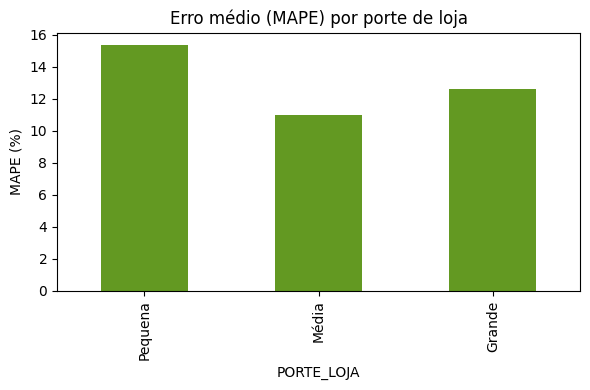


MAPE por período (ano/mês):
ANO   MES
2023  1      31.26
      2      13.72
      3      10.37
      4      15.26
      5      10.87
      6      12.43
      7       9.87
      8      10.57
      9      11.22
      10     11.64
Name: erro_abs_pct, dtype: float64


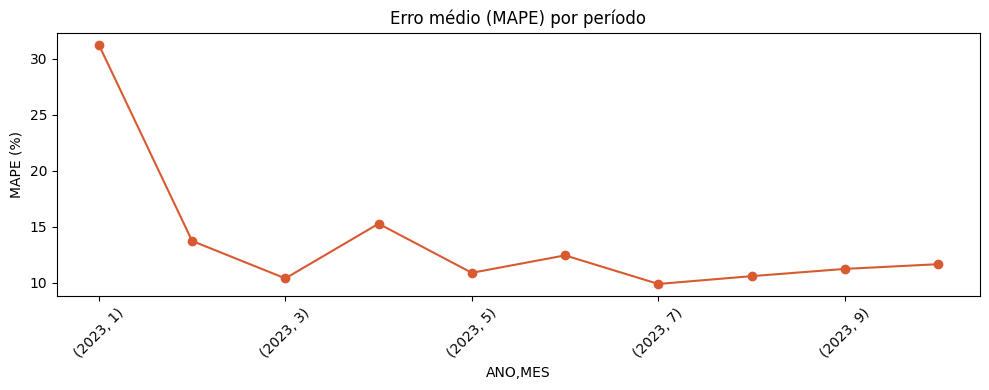


Top 5 lojas com maior erro médio:
LOJA
S - Lumiar               122.67
S - Conde Redondo         31.75
S - Avenida Republica     19.61
S - Pedro Nunes           19.26
Guimarães                 17.49
Name: erro_abs_pct, dtype: float64


In [0]:
# ==================================================================
# 3) SEGMENTAÇÃO DE ERRO — por região, porte de loja e período
# ==================================================================

test_full_pd = test_pred.select(
    "DATA", "LOJA", "N_COLABORADORES",
    "TARGET_VENDAS_DIARIAS_EUR", "prediction"
).toPandas()

test_full_pd["ANO"] = pd.to_datetime(test_full_pd["DATA"]).dt.year
test_full_pd["MES"] = pd.to_datetime(test_full_pd["DATA"]).dt.month
test_full_pd["erro_abs_pct"] = (
    (test_full_pd["TARGET_VENDAS_DIARIAS_EUR"] - test_full_pd["prediction"]).abs()
    / test_full_pd["TARGET_VENDAS_DIARIAS_EUR"].abs()
) * 100

# Porte de loja (tercis por nº de colaboradores)
test_full_pd["PORTE_LOJA"] = pd.qcut(
    test_full_pd["N_COLABORADORES"], q=3, labels=["Pequena", "Média", "Grande"]
)

# --- Por porte de loja ---
mape_porte = test_full_pd.groupby("PORTE_LOJA", observed=True)["erro_abs_pct"].mean()
print("\nMAPE por porte de loja:")
print(mape_porte.round(2))

plt.figure(figsize=(6, 4))
mape_porte.plot(kind="bar", color="#639922")
plt.ylabel("MAPE (%)")
plt.title("Erro médio (MAPE) por porte de loja")
plt.tight_layout()
plt.show()

# --- Por período (ano/mês) ---
mape_periodo = test_full_pd.groupby(["ANO", "MES"])["erro_abs_pct"].mean()
print("\nMAPE por período (ano/mês):")
print(mape_periodo.round(2))

plt.figure(figsize=(10, 4))
mape_periodo.plot(kind="line", marker="o", color="#D85A30")
plt.ylabel("MAPE (%)")
plt.title("Erro médio (MAPE) por período")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Top 5 lojas com pior MAPE ---
mape_loja = test_full_pd.groupby("LOJA")["erro_abs_pct"].mean().sort_values(ascending=False)
print("\nTop 5 lojas com maior erro médio:")
print(mape_loja.head(5).round(2))

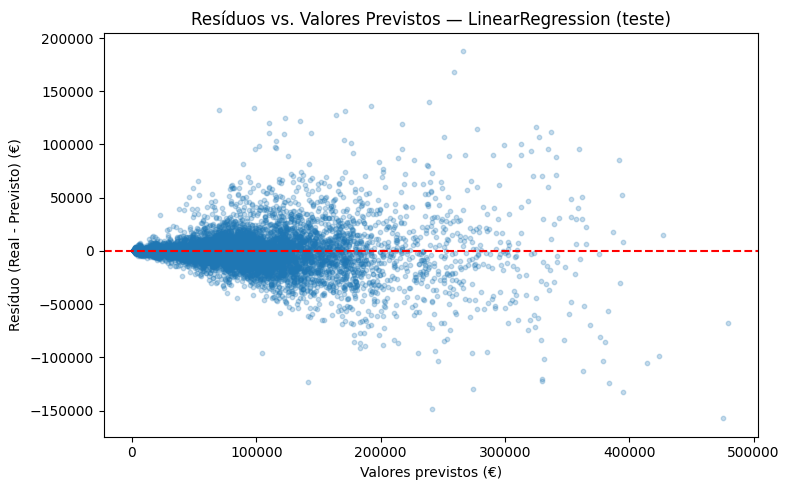

Resíduo médio: -356.98 €  (idealmente próximo de 0)
Desvio padrão do resíduo: 12,557.81 €
Sem indício forte de viés sistemático (resíduo médio próximo de zero).


In [0]:
# ==================================================================
# 1) ANÁLISE DE RESÍDUOS — Residuals vs. Fitted Values
# Objetivo: verificar se existe viés sistemático (padrão nos resíduos)
# ==================================================================

test_pred_pd = test_pred.select("TARGET_VENDAS_DIARIAS_EUR", "prediction").toPandas()
test_pred_pd["residual"] = test_pred_pd["TARGET_VENDAS_DIARIAS_EUR"] - test_pred_pd["prediction"]

plt.figure(figsize=(8, 5))
plt.scatter(test_pred_pd["prediction"], test_pred_pd["residual"], alpha=0.25, s=10)
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.xlabel("Valores previstos (€)")
plt.ylabel("Resíduo (Real - Previsto) (€)")
plt.title("Resíduos vs. Valores Previstos — LinearRegression (teste)")
plt.tight_layout()
plt.show()

media_residual = test_pred_pd["residual"].mean()
desvio_residual = test_pred_pd["residual"].std()

print(f"Resíduo médio: {media_residual:,.2f} €  (idealmente próximo de 0)")
print(f"Desvio padrão do resíduo: {desvio_residual:,.2f} €")

if abs(media_residual) > 0.05 * test_pred_pd["TARGET_VENDAS_DIARIAS_EUR"].mean():
    print("Atenção: possível viés sistemático — o resíduo médio é elevado face à escala da target.")
else:
    print("Sem indício forte de viés sistemático (resíduo médio próximo de zero).")

                feature  coeficiente  coeficiente_abs
12    EVENTO_FIM_SEMANA   -21550.809        21550.809
11             IS_EVENT   -12996.104        12996.104
13       IS_REG_LIS_NOR      837.020          837.020
1       N_COLABORADORES      179.476          179.476
2        SELF_CHECKOUTS       61.816           61.816
9   CAIXAS_TRADICIONAIS      -46.796           46.796
0    PRODUTIVIDADE/HORA        3.183            3.183
8    ROLL_AVG_14_VENDAS       -0.555            0.555
7     ROLL_AVG_7_VENDAS        0.551            0.551
4          LAG_7_VENDAS        0.397            0.397
10               SKUS_+        0.199            0.199
5         LAG_14_VENDAS        0.184            0.184
3          LAG_1_VENDAS        0.176            0.176
6     ROLL_AVG_1_VENDAS        0.176            0.176


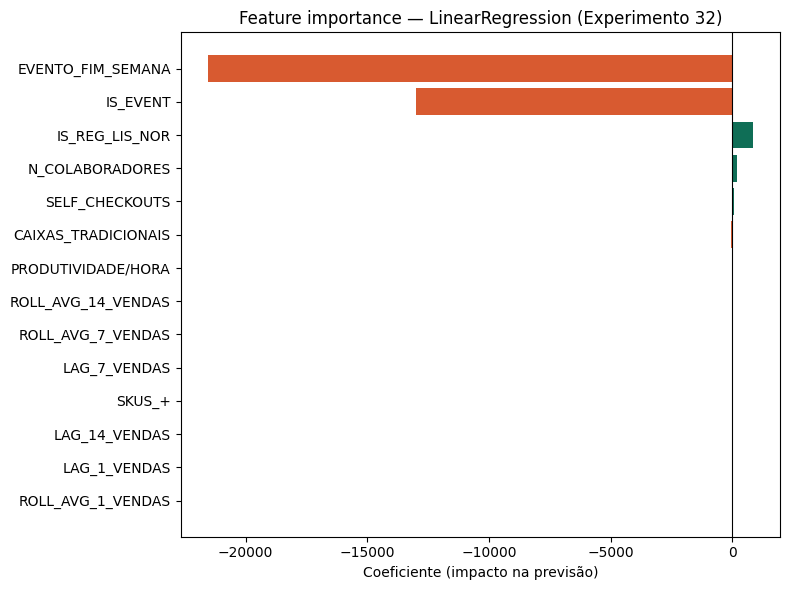


Verde = impacto positivo nas vendas | Vermelho = impacto negativo


In [0]:
# ==================================================================
# 4) FEATURE IMPORTANCE — quais inputs mais pesam na previsão
# (LinearRegression: coeficientes; equivalente ao feature_importances_
# dos modelos de árvore usado no Experimento 32)
# ==================================================================

lr_stage = fitted_champion.stages[-1]
coeficientes = lr_stage.coefficients.toArray()

importancia = pd.DataFrame({
    "feature": feature_columns,
    "coeficiente": coeficientes,
    "coeficiente_abs": np.abs(coeficientes),
}).sort_values("coeficiente_abs", ascending=False)

print(importancia.round(3))

plt.figure(figsize=(8, 6))
cores = ["#D85A30" if c < 0 else "#0F6E56" for c in importancia["coeficiente"]]
plt.barh(importancia["feature"], importancia["coeficiente"], color=cores)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (impacto na previsão)")
plt.title("Feature importance — LinearRegression (Experimento 32)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nVerde = impacto positivo nas vendas | Vermelho = impacto negativo")

In [0]:
# Create schema to RetailCast data
spark.sql("""
CREATE SCHEMA IF NOT EXISTS p2_retailcast.retailcast_forecast
""")

DataFrame[]

In [0]:
"""
RetailCast - Inferência Multi-Loja e Multi-Horizonte
====================================================================
Gera previsões para cada loja, em 3 horizontes (1, 7 e 14 dias),
usando o modelo único já treinado (as 14 features do Experimento 32).

Como o modelo foi treinado para um único alvo (TARGET_VENDAS_DIARIAS_EUR,
usando sempre features "olhando para trás" a partir da data de cada linha),
NÃO existem 3 modelos distintos -- existe 1 modelo aplicado a 3 pontos de
referência temporal diferentes por loja:

  h=1  -> usa a linha de dados na data de corte (cutoff) de cada loja
  h=7  -> usa a linha de dados de ~7 posições antes do cutoff
  h=14 -> usa a linha de dados de ~14 posições antes do cutoff

CORREÇÃO: o cutoff de referência é agora ÚNICO e comum a todas as lojas
(a data mais recente que TODAS as lojas têm em comum), em vez de "a última
data disponível de cada loja" individualmente. Isto garante que as
previsões h=1/7/14 de lojas diferentes são comparáveis entre si -- todas
partem do mesmo ponto no tempo, não de datas de corte diferentes por loja.

Resultado esperado: 3 previsões por loja (uma por horizonte) -- ou seja,
nº_lojas x 3 linhas no total.

IMPORTANTE (limitação a documentar no relatório): isto NÃO é um forecast
real "a 7 ou 14 dias no futuro" no sentido causal -- é uma aproximação que
reaproveita o mesmo modelo com contexto mais antigo, porque o modelo não
foi treinado para prever alvos deslocados no tempo (isso exigiria o
forecasting direto multi-horizonte que discutimos antes, com LEAD(target,h)
como novo alvo, e que foi deixado fora do CV a pedido). Para produção real,
o correto seria treinar 3 modelos (ou um multi-output) com targets
deslocados -- isto aqui serve como aproximação rápida com o modelo atual.
"""

import mlflow.pyfunc
import pandas as pd
import numpy as np
import os
from pyspark.sql.functions import col, row_number, min as spark_min, max as spark_max
from pyspark.sql.window import Window

os.environ["MLFLOW_DFS_TMP"] = "/Volumes/p2_retailcast/retailcast_ml_featuring/mlflow_artifacts"

mlflow.set_experiment("/Users/brenofontesx@gmail.com/retailcast_models")
runs = mlflow.search_runs(order_by=["start_time DESC"], max_results=1)

if len(runs) == 0:
    raise ValueError(
        "No models found in /Users/brenofontesx@gmail.com/retailcast_models experiment. "
        "Please run the training cell first to train and log models."
    )

latest_run_id = runs.iloc[0]["run_id"]
model_uri = f"runs:/{latest_run_id}/model"
model = mlflow.pyfunc.load_model(model_uri)

# ==============================================================================
# 0. Config -- faixas de erro vindas da CV walk-forward (retailcast_cv_features.py)
# ==============================================================================
HORIZONTES = [1, 7, 14]
MAPE_TIPICO_MAX = 0.29     # pior fold em condição normal
MAPE_DISRUPCAO = 0.92      # fold em período de disrupção tipo COVID
LOJAS_COM_GAP_CONHECIDO = []          # preencher com a lista real do EDA
PERIODO_DISRUPCAO = [("2020-08-29", "2021-05-31")]

FEATURE_COLS = [
    "PRODUTIVIDADE/HORA", "N_COLABORADORES", "SELF_CHECKOUTS",
    "LAG_1_VENDAS", "LAG_7_VENDAS", "LAG_14_VENDAS",
    "ROLL_AVG_1_VENDAS", "ROLL_AVG_7_VENDAS", "ROLL_AVG_14_VENDAS",
    "CAIXAS_TRADICIONAIS", "SKUS_+", "IS_EVENT", "EVENTO_FIM_SEMANA", "IS_REG_LIS_NOR",
]

# ==============================================================================
# 1. Carregar dados por loja (FK_LOJA é indispensável para ranking e
#    previsões por loja)
# ==============================================================================
df_recente = spark.sql("""
SELECT
    DATA,
    LOJA,
    CAST(`PRODUTIVIDADE/HORA` AS DOUBLE) AS `PRODUTIVIDADE/HORA`,
    CAST(N_COLABORADORES AS INT) AS N_COLABORADORES,
    CAST(SELF_CHECKOUTS AS INT) AS SELF_CHECKOUTS,
    CAST(LAG_1_VENDAS AS DOUBLE) AS LAG_1_VENDAS,
    CAST(LAG_7_VENDAS AS DOUBLE) AS LAG_7_VENDAS,
    CAST(LAG_14_VENDAS AS DOUBLE) AS LAG_14_VENDAS,
    CAST(ROLL_AVG_1_VENDAS AS DOUBLE) AS ROLL_AVG_1_VENDAS,
    CAST(ROLL_AVG_7_VENDAS AS DOUBLE) AS ROLL_AVG_7_VENDAS,
    CAST(ROLL_AVG_14_VENDAS AS DOUBLE) AS ROLL_AVG_14_VENDAS,
    CAST(CAIXAS_TRADICIONAIS AS INT) AS CAIXAS_TRADICIONAIS,
    CAST(`SKUS_+` AS INT) AS `SKUS_+`,
    CAST(IS_EVENT AS INT) AS IS_EVENT,
    CAST(EVENTO_FIM_SEMANA AS INT) AS EVENTO_FIM_SEMANA,
    CAST(IS_REG_LIS_NOR AS INT) AS IS_REG_LIS_NOR
FROM p2_retailcast.retailcast_ml_featuring.retailcast_ml_features_v2
WHERE LAG_14_VENDAS IS NOT NULL AND ROLL_AVG_14_VENDAS IS NOT NULL
""").withColumn("DATA", col("DATA").cast("date"))

# ==============================================================================
# 1b. CORREÇÃO: Determinar um cutoff ÚNICO, comum a todas as lojas.
#     -> a última data que TODAS as lojas têm em comum (o mínimo entre os
#        máximos de DATA por loja), para que h=1/7/14 partam do mesmo
#        ponto no tempo em todas as lojas, e não de datas diferentes.
# ==============================================================================
max_data_por_loja = df_recente.groupBy("LOJA").agg(spark_max("DATA").alias("max_data"))
cutoff_row = max_data_por_loja.agg(spark_min("max_data").alias("cutoff")).first()
CUTOFF_DATE = cutoff_row["cutoff"]

print(f"Cutoff de referência (comum a todas as lojas): {CUTOFF_DATE}")

# Mantém só dados até ao cutoff -- garante que h=1/7/14 nunca "veem" dados
# posteriores ao ponto de referência comum
df_recente = df_recente.filter(col("DATA") <= CUTOFF_DATE)

# rn=1 -> data do cutoff (ou mais próxima anterior) por loja
# rn=7 -> ~7 posições antes do cutoff; rn=14 -> ~14 posições antes
w = Window.partitionBy("LOJA").orderBy(col("DATA").desc())
df_ranqueado = df_recente.withColumn("rn", row_number().over(w))
df_ranqueado_pd = df_ranqueado.filter(col("rn").isin(HORIZONTES)).toPandas()

# ==============================================================================
# 2. Intervalos de treino por feature (para deteção de extrapolação) -- calculados
#    sobre os dados reais, não valores fixos.
# ==============================================================================
resumo = df_recente.select(FEATURE_COLS).summary("min", "max").toPandas().set_index("summary")
RANGES_TREINO = {f: (float(resumo.loc["min", f]), float(resumo.loc["max", f])) for f in FEATURE_COLS}


def avaliar_confianca(input_row: dict, data_referencia, fk_loja: str):
    avisos = []
    for feat, (min_v, max_v) in RANGES_TREINO.items():
        val = input_row.get(feat)
        if val is not None and (val < min_v or val > max_v):
            avisos.append(f"'{feat}'={val:.1f} fora do intervalo observado [{min_v:.1f}, {max_v:.1f}]")

    if fk_loja in LOJAS_COM_GAP_CONHECIDO:
        avisos.append(f"Loja {fk_loja} tem histórico de dados em falta em 2023 (ver EDA)")

    data_str = str(data_referencia)
    for ini, fim in PERIODO_DISRUPCAO:
        if ini <= data_str <= fim:
            avisos.append(f"Data de referência {data_str} cai num período de disrupção conhecido")

    return avisos


# ==============================================================================
# 3. Gerar previsão por loja e por horizonte, a partir do cutoff comum
# ==============================================================================
resultados = []

lojas_unicas = df_ranqueado_pd["LOJA"].unique()

for loja in lojas_unicas:
    grupo_loja = df_ranqueado_pd[df_ranqueado_pd["LOJA"] == loja]
    for h in HORIZONTES:
        linha = grupo_loja[grupo_loja["rn"] == h]
        if linha.empty:
            resultados.append({
                "LOJA": loja, "horizonte_dias": h,
                "previsao_central": None, "intervalo_min": None, "intervalo_max": None,
                "nivel_confianca": "SEM DADOS",
                "avisos": f"Sem histórico suficiente ({h} posições antes do cutoff) para esta loja",
            })
            continue

        linha = linha.iloc[0]
        input_row = {f: linha[f] for f in FEATURE_COLS}
        input_data = pd.DataFrame([input_row])

        # Cast columns to match model signature types
        input_data = input_data.astype({
            "PRODUTIVIDADE/HORA": float,
            "LAG_1_VENDAS": float,
            "LAG_7_VENDAS": float,
            "LAG_14_VENDAS": float,
            "ROLL_AVG_1_VENDAS": float,
            "ROLL_AVG_7_VENDAS": float,
            "ROLL_AVG_14_VENDAS": float,
        })

        pred_central = float(model.predict(input_data)[0])

        avisos = avaliar_confianca(input_row, linha["DATA"], loja)
        em_disrupcao = any("disrupção" in a for a in avisos)
        mape_faixa = MAPE_DISRUPCAO if em_disrupcao else MAPE_TIPICO_MAX

        import builtins
        resultados.append({
            "LOJA": loja,
            "horizonte_dias": h,
            "cutoff_referencia": CUTOFF_DATE,
            "data_referencia": linha["DATA"],
            "previsao_central": builtins.round(pred_central, 2),
            "intervalo_min": builtins.round(builtins.max(pred_central * (1 - mape_faixa), 0), 2),
            "intervalo_max": builtins.round(pred_central * (1 + mape_faixa), 2),
            "nivel_confianca": "BAIXA" if avisos else "NORMAL",
            "avisos": "; ".join(avisos) if avisos else "",
        })

df_resultados = pd.DataFrame(resultados)

print(f"\nPrevisões geradas: {len(df_resultados)} linhas "
      f"({df_resultados['LOJA'].nunique()} lojas x {len(HORIZONTES)} horizontes)\n")
print(df_resultados.sort_values(["LOJA", "horizonte_dias"]).to_string(index=False))

n_baixa_confianca = (df_resultados["nivel_confianca"] == "BAIXA").sum()
print(f"\n{n_baixa_confianca} previsões sinalizadas com confiança BAIXA (de {len(df_resultados)} totais).")

# Opcional: gravar como tabela Delta para consumo no PowerBI
# spark.createDataFrame(df_resultados).write.format("delta").mode("overwrite") \
#     .saveAsTable("p2_retailcast.retailcast_ml_featuring.previsoes_multihorizonte")

Cutoff de referência (comum a todas as lojas): 2023-10-30

Previsões geradas: 210 linhas (70 lojas x 3 horizontes)

                           LOJA  horizonte_dias cutoff_referencia data_referencia  previsao_central  intervalo_min  intervalo_max nivel_confianca avisos
                      Alfragide               1        2023-10-30      2023-10-30         240985.53      171099.73      310871.34          NORMAL       
                      Alfragide               7        2023-10-30      2023-10-24         165051.51      117186.57      212916.44          NORMAL       
                      Alfragide              14        2023-10-30      2023-10-17         151440.79      107522.96      195358.62          NORMAL       
                   Almada Fórum               1        2023-10-30      2023-10-30         270551.20      192091.36      349011.05          NORMAL       
                   Almada Fórum               7        2023-10-30      2023-10-24         247417.96      175666.75     

In [0]:
spark.createDataFrame(df_resultados).write.format("delta").mode("overwrite") \
    .saveAsTable("p2_retailcast.retailcast_forecast.retail_forecast_1_7_14")

In [0]:
# ==================================================================
# CUSTO COMPUTACIONAL — Tempo e Memória (Treino + Inferência)
# CORREÇÃO: usa os dados REAIS do RetailCast (as mesmas 14 features e
# o mesmo volume de registos usados no Experimento 32), em vez de
# dados dummy gerados com make_regression -- para que o custo medido
# reflita o cenário real de produção, e inclui também o custo de
# INFERÊNCIA (não só de treino), que é o que importa para servir
# previsões no dia a dia.
# ==================================================================

import time
import tracemalloc
import pandas as pd
from sklearn.linear_model import LinearRegression as SkLinearRegression
from sklearn.tree import DecisionTreeRegressor as SkDecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor as SkRandomForestRegressor

# 1. Dados reais (reaproveita train_diag/test_diag da célula de diagnóstico;
#    caso não existam na sessão, recarrega da tabela Gold)
try:
    train_diag
    test_diag
    feature_columns
except NameError:
    from pyspark.sql.functions import col, year
    feature_columns = [
        "PRODUTIVIDADE/HORA", "N_COLABORADORES", "SELF_CHECKOUTS",
        "LAG_1_VENDAS", "LAG_7_VENDAS", "LAG_14_VENDAS",
        "ROLL_AVG_1_VENDAS", "ROLL_AVG_7_VENDAS", "ROLL_AVG_14_VENDAS",
        "CAIXAS_TRADICIONAIS", "SKUS_+", "IS_EVENT", "EVENTO_FIM_SEMANA", "IS_REG_LIS_NOR",
    ]
    df_custo_base = spark.sql("""
    SELECT
        CAST(TARGET_VENDAS_DIARIAS_EUR AS DOUBLE) AS TARGET_VENDAS_DIARIAS_EUR,
        DATA,
        CAST(`PRODUTIVIDADE/HORA` AS DOUBLE) AS `PRODUTIVIDADE/HORA`,
        CAST(N_COLABORADORES AS INT) AS N_COLABORADORES,
        CAST(SELF_CHECKOUTS AS INT) AS SELF_CHECKOUTS,
        CAST(LAG_1_VENDAS AS DOUBLE) AS LAG_1_VENDAS,
        CAST(LAG_7_VENDAS AS DOUBLE) AS LAG_7_VENDAS,
        CAST(LAG_14_VENDAS AS DOUBLE) AS LAG_14_VENDAS,
        CAST(ROLL_AVG_1_VENDAS AS DOUBLE) AS ROLL_AVG_1_VENDAS,
        CAST(ROLL_AVG_7_VENDAS AS DOUBLE) AS ROLL_AVG_7_VENDAS,
        CAST(ROLL_AVG_14_VENDAS AS DOUBLE) AS ROLL_AVG_14_VENDAS,
        CAST(CAIXAS_TRADICIONAIS AS INT) AS CAIXAS_TRADICIONAIS,
        CAST(`SKUS_+` AS INT) AS `SKUS_+`,
        CAST(IS_EVENT AS INT) AS IS_EVENT,
        CAST(EVENTO_FIM_SEMANA AS INT) AS EVENTO_FIM_SEMANA,
        CAST(IS_REG_LIS_NOR AS INT) AS IS_REG_LIS_NOR
    FROM p2_retailcast.retailcast_ml_featuring.retailcast_ml_features_v2
    WHERE TARGET_VENDAS_DIARIAS_EUR IS NOT NULL
      AND LAG_14_VENDAS IS NOT NULL
      AND ROLL_AVG_14_VENDAS IS NOT NULL
    """)
    train_diag = df_custo_base.filter(year(col("DATA")) < 2023)
    test_diag = df_custo_base.filter(year(col("DATA")) >= 2023)

train_pd_cost = train_diag.select(feature_columns + ["TARGET_VENDAS_DIARIAS_EUR"]).toPandas().dropna()
test_pd_cost = test_diag.select(feature_columns + ["TARGET_VENDAS_DIARIAS_EUR"]).toPandas().dropna()

X_train = train_pd_cost[feature_columns].values
y_train = train_pd_cost["TARGET_VENDAS_DIARIAS_EUR"].values
X_test = test_pd_cost[feature_columns].values

print(f"Dados reais: {len(X_train):,} registos de treino, {len(X_test):,} de teste, "
      f"{len(feature_columns)} features\n")

# 2. Modelos -- os mesmos 3 comparados no Experimento 32
modelos = {
    "Linear Regression": SkLinearRegression(),
    "Decision Tree": SkDecisionTreeRegressor(random_state=42),
    "Random Forest": SkRandomForestRegressor(n_estimators=100, random_state=42),
}

# 3. Função de avaliação de custo -- treino + inferência
def avaliar_custo(nome_modelo, modelo, X_train, y_train, X_test):
    print(f"--- {nome_modelo} ---")

    # --- Treino ---
    tracemalloc.start()
    t0 = time.time()
    modelo.fit(X_train, y_train)
    t1 = time.time()
    _, pico_treino = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    tempo_treino = t1 - t0
    pico_treino_mb = pico_treino / (1024 * 1024)

    # --- Inferência ---
    tracemalloc.start()
    t0 = time.time()
    modelo.predict(X_test)
    t1 = time.time()
    _, pico_inferencia = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    tempo_inferencia = t1 - t0
    pico_inferencia_mb = pico_inferencia / (1024 * 1024)
    tempo_inferencia_por_registo_ms = (tempo_inferencia / len(X_test)) * 1000

    print(f"Treino     -> tempo: {tempo_treino:.4f}s | pico RAM: {pico_treino_mb:.2f} MB")
    print(f"Inferência -> tempo total: {tempo_inferencia:.4f}s | "
          f"por registo: {tempo_inferencia_por_registo_ms:.4f} ms | pico RAM: {pico_inferencia_mb:.2f} MB\n")

    return {
        "modelo": nome_modelo,
        "tempo_treino_s": tempo_treino,
        "ram_treino_mb": pico_treino_mb,
        "tempo_inferencia_s": tempo_inferencia,
        "tempo_inferencia_ms_por_registo": tempo_inferencia_por_registo_ms,
        "ram_inferencia_mb": pico_inferencia_mb,
    }

# 4. Executar para os 3 modelos e resumir
resultados_custo = [
    avaliar_custo(nome, modelo, X_train, y_train, X_test)
    for nome, modelo in modelos.items()
]

df_custo = pd.DataFrame(resultados_custo).set_index("modelo")
print("Resumo comparativo (treino + inferência):")
print(df_custo.round(4))

Dados reais: 77,436 registos de treino, 20,219 de teste, 14 features

--- Linear Regression ---
Treino     -> tempo: 0.0751s | pico RAM: 17.75 MB
Inferência -> tempo total: 0.0009s | por registo: 0.0000 ms | pico RAM: 0.31 MB

--- Decision Tree ---
Treino     -> tempo: 1.6124s | pico RAM: 5.04 MB
Inferência -> tempo total: 0.0071s | por registo: 0.0004 ms | pico RAM: 1.39 MB

--- Random Forest ---
Treino     -> tempo: 101.4740s | pico RAM: 11.23 MB
Inferência -> tempo total: 0.4889s | por registo: 0.0242 ms | pico RAM: 1.56 MB

Resumo comparativo (treino + inferência):
                   tempo_treino_s  ...  ram_inferencia_mb
modelo                             ...                   
Linear Regression          0.0751  ...             0.3091
Decision Tree              1.6124  ...             1.3902
Random Forest            101.4740  ...             1.5563

[3 rows x 5 columns]
